# Local Ancestry Segment Analysis

## Statistical Evaluation of Ancestry Tract Lengths Along a Chromosome

---

This notebook develops a complete framework for analysing **local ancestry** along a chromosome
in an admixed population. The scenario is:

- A **resident population** contributes a fraction $f_r = 0.7$ of the genome.
- An **invading population** contributes a fraction $f_i = 0.3$ (an instantaneous admixture event
  at time $t$ generations ago).
- Each chromosome carries consecutive segments coloured as either *resident* or *foreign*
  (invader) ancestry.

We address three questions:

1. **How probable is a segment of observed length?**  
   → Compute an $n \times n$ probability matrix $P[i,j]$ over loci.

2. **What does the per-position probability landscape look like?**  
   → Simulate chromosomes, compute and plot mean probabilities per position.

3. **Which positions carry anomalously long segments?**  
   → Convert probabilities to p-values, apply multiple-testing correction,
   and run a joint test across both ancestry classes.

---

### Contents

1. [Background & Mathematical Model](#section-1)  
2. [Genetic Map Setup](#section-2)  
3. [Ancestry Segment Probability Matrix](#section-3)  
4. [Chromosome Simulation](#section-4)  
5. [Per-Position Mean Probabilities](#section-5)  
6. [Significance Testing](#section-6)  


## 0 · Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from scipy.stats import chi2
import seaborn as sns

# Reproducibility
np.random.seed(42)

from vscodenb import set_vscode_theme, vscode_theme
set_vscode_theme(style='ticks')
plt.set_cmap('tab10')
sns.set_palette('tab10')


<Figure size 500x370 with 0 Axes>

In [2]:

# Plotting style
#BG, TC, GC = '#0f0f1a', '#aaaacc', '#222244'
COLOR = {'resident': 'C1', 'foreign': 'C2', 'joint': 'C3', 'both': 'C4'}

# def style_ax(ax):
#     ax.set_facecolor(BG)
#     ax.tick_params(colors=TC, labelsize=8)
#     for sp in ax.spines.values():
#         sp.set_edgecolor(GC)
#     ax.yaxis.grid(True, color=GC, lw=0.5, alpha=0.7)
#     ax.xaxis.grid(True, color=GC, lw=0.5, alpha=0.4)


---
<a id="section-1"></a>
## 1 · Background & Mathematical Model

### 1.1 The Admixture Model

We model a **single pulse of admixture** at generation $t$ in the past, in which a fraction
$f_i = 0.3$ of the population's ancestry derives from an invading population and
$f_r = 0.7$ from the resident population.

After the admixture event, **recombination** progressively breaks down the long ancestry
tracts inherited from each parental population. Under this model, the lengths of
ancestry tracts at generation $t$ follow an **exponential distribution** whose rate
depends on the ancestry class.

### 1.2 Expected Tract Length Distribution

Let $G$ denote tract length in **Morgans** (genetic distance units). Under the
standard admixture-tract model (Pool & Nielsen 2009; Gravel 2012):

$$G \sim \text{Exponential}(\lambda) \quad \text{with} \quad \lambda = f \cdot t$$

where:
- $f$ is the frequency of the *other* ancestry (the probability of a recombination
  event landing in a foreign-ancestry background and ending the tract),
- $t$ is the time in generations since admixture.

The mean tract length is therefore:

$$\mathbb{E}[G] = \frac{1}{f \cdot t} \quad \text{(Morgans)}$$

Converting to physical units via the local recombination rate $r$ (Morgans per bp):

$$\mathbb{E}[L] = \frac{1}{r \cdot f \cdot t} \quad \text{(base pairs)}$$

### 1.3 The Probability Matrix

For a chromosome with loci indexed $i = 0, \ldots, n-1$, define:

$$P[i,j] = P\!\left(G \geq g(i,j)\right) = \exp\!\left(-f \cdot g(i,j) \cdot t\right)$$

where $g(i,j) = |G_j - G_i|$ is the **genetic distance** between loci $i$ and $j$
obtained from the genetic map.

The **ancestry class** determines $f$:

| Region | Ancestry | $f$ |
|--------|----------|-----|
| Upper triangle ($j > i$) | Resident | $f_r = 0.7$ |
| Lower triangle ($j < i$) | Invader  | $f_i = 0.3$ |
| Diagonal ($i = j$) | — | $P = 1$ |

This asymmetry arises because resident tracts are broken by recombination into
*foreign* backgrounds (rate $f_i$) and foreign tracts are broken by recombination
into *resident* backgrounds (rate $f_r$).

### 1.4 Connection to the Survival Function and p-values

The key insight is that $P[i,j]$ **is simultaneously the survival function of the
null distribution**:

$$P[i,j] = P(G \geq g_{ij} \mid H_0) \equiv p\text{-value}$$

A small value of $P[i,j]$ therefore indicates that the observed tract spanning
positions $i$ to $j$ is longer than expected under the null model — i.e., a
statistically significant signal. No separate test statistic is required.


---
<a id="section-2"></a>
## 2 · Genetic Map

A **genetic map** provides the cumulative recombination distance (in Morgans or cM)
as a function of physical position (in bp). The key quantity is the **recombination
rate** $r$ (Morgans per bp), which converts physical distances into genetic distances.

We use a synthetic map here; in practice, replace the arrays below with columns
read from a real map file (e.g. HapMap, deCODE, or an organism-specific map).

### Parameter choices

We use $r \approx 10^{-7}$ M/bp (10× the typical human average) and $t = 100$
generations, giving:

$$\mathbb{E}[L_r] = \frac{1}{r \cdot 0.7 \cdot 100} \approx 143 \text{ kb}, \quad
  \mathbb{E}[L_i] = \frac{1}{r \cdot 0.3 \cdot 100} \approx 333 \text{ kb}$$

These lengths comfortably fit within the 5 Mb chromosome and produce multi-segment
chromosomes suitable for illustration.

> **Note on parameter scaling**: The product $r \cdot t$ is what determines
> segment lengths. Increasing $t$ at lower $r$ (or vice versa) gives identical
> distributions. The human genome average ($r \approx 10^{-8}$ M/bp) with
> $t = 1000$ generations gives similar segment lengths.


In [52]:
# ── Simulation parameters ────────────────────────────────────────────────────
CHROM_LENGTH  = 5_000_000   # bp
N_MAP_POINTS  = 500
N_CHROMOSOMES = 10
T             = 100          # generations since admixture
F_RES         = 0.7          # resident ancestry frequency
F_INV         = 0.3          # invader  ancestry frequency
N_EVAL        = 3000         # evaluation positions for per-position plots
ALPHA         = 0.05         # significance level

# ── Build synthetic genetic map ──────────────────────────────────────────────
rng_map       = np.random.default_rng(seed=42)
physical_map  = np.linspace(0, CHROM_LENGTH, N_MAP_POINTS)   # bp
rate_per_bp   = 1e-7 * (1 + 0.5 * rng_map.random(N_MAP_POINTS))  # Morgans/bp, with spatial variation

rate_per_bp *= 10 

# ------------------------------------------------------------
# # Add a large-scale wave pattern to the recombination rate, to make it more realistic
# wave = np.sin(physical_map/100000)/2 + 0.5
# rate_per_bp *= wave * 10
# ------------------------------------------------------------

genetic_map   = np.cumsum(rate_per_bp * np.diff(physical_map, prepend=0))  # cumulative Morgans

r = genetic_map[-1] / CHROM_LENGTH    # mean recombination rate

# Interpolation function: physical bp → genetic Morgans
phys_to_gen = interp1d(physical_map, genetic_map,
                        bounds_error=False, fill_value='extrapolate')

print(f"Chromosome length : {CHROM_LENGTH/1e6:.1f} Mb")
print(f"Total map length  : {genetic_map[-1]*100:.2f} cM")
print(f"Mean rate r       : {r:.3e} Morgans/bp")
print()
for label, f in [('Resident', F_RES), ('Invader', F_INV)]:
    mean_bp = 1.0 / (r * f * T)
    print(f"{label}: E[length] = {mean_bp/1e3:.1f} kb  |  "
          f"E[genetic length] = {1/(f*T)*100:.3f} cM")


Chromosome length : 5.0 Mb
Total map length  : 623.78 cM
Mean rate r       : 1.248e-06 Morgans/bp

Resident: E[length] = 11.5 kb  |  E[genetic length] = 1.429 cM
Invader: E[length] = 26.7 kb  |  E[genetic length] = 3.333 cM


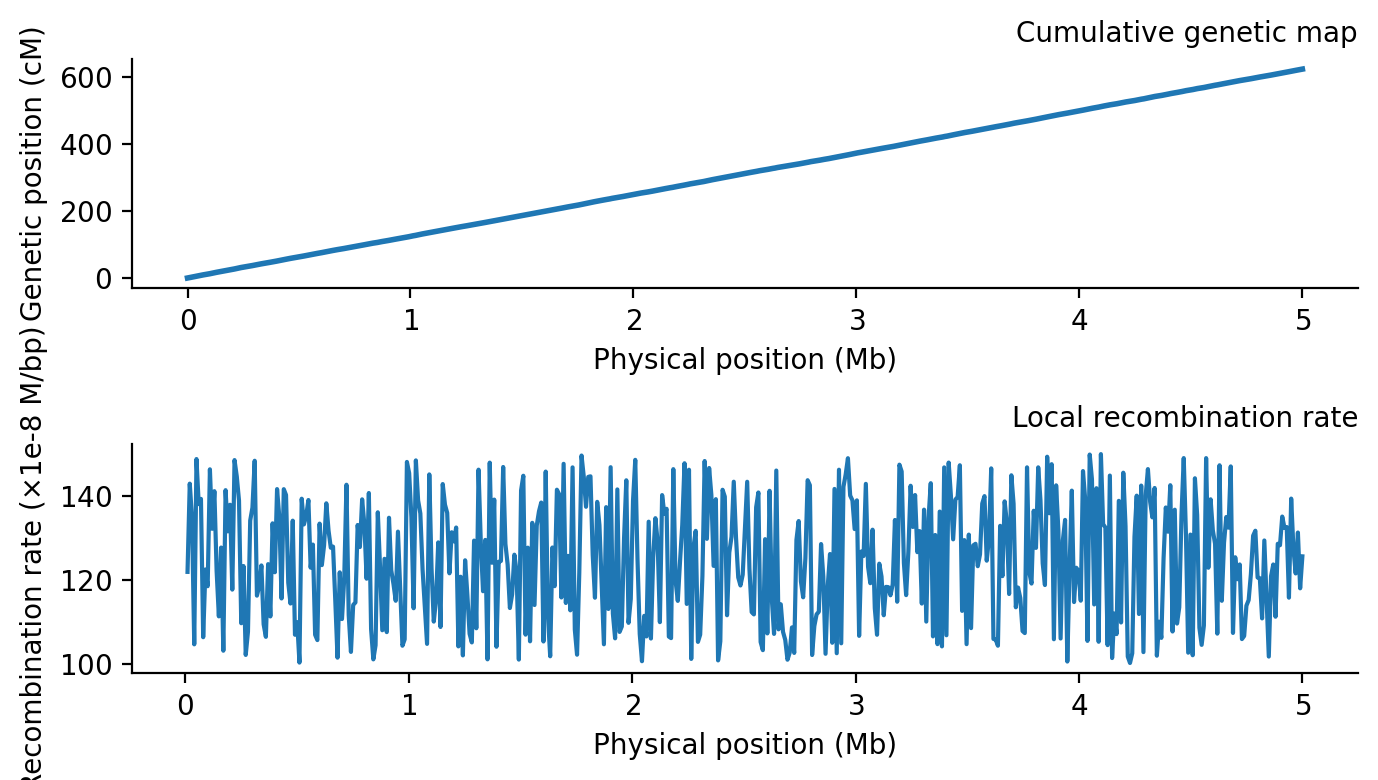

In [53]:
# ── Plot the genetic map ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(7, 4))
#fig.patch.set_facecolor(BG)

ax = axes[0]
#style_ax(ax)
ax.plot(physical_map/1e6, genetic_map*100, lw=2)
ax.set_xlabel('Physical position (Mb)')
ax.set_ylabel('Genetic position (cM)')
ax.set_title('Cumulative genetic map')

ax = axes[1]
#style_ax(ax)
# local rate = diff(genetic_map) / diff(physical_map)
local_rate = np.diff(genetic_map) / np.diff(physical_map)
ax.plot(physical_map[1:]/1e6, local_rate * 1e8)
ax.set_xlabel('Physical position (Mb)')
ax.set_ylabel('Recombination rate (×1e-8 M/bp)')
ax.set_title('Local recombination rate')

plt.tight_layout()
plt.show()


---
<a id="section-3"></a>
## 3 · Ancestry Segment Probability Matrix

### 3.1 Construction

The matrix $P \in \mathbb{R}^{n \times n}$ is computed in three vectorised steps:

1. **Signed distance matrix**:
$$G[i,j] = \text{gpos}[j] - \text{gpos}[i]$$

2. **Frequency mask**:
$$F[i,j] = \begin{cases} f_r & G[i,j] > 0 \\ f_i & G[i,j] < 0 \\ 1 & G[i,j] = 0 \end{cases}$$

3. **Probability**:
$$P[i,j] = \exp\!\left(-F[i,j] \cdot |G[i,j]| \cdot t\right)$$

The computation is $O(n^2)$ in both time and memory.

### 3.2 Interpretation

- **Near the diagonal**: short genetic distances → probabilities close to 1.
  Every position is part of *some* segment, however short.
- **Off-diagonal decay**: longer tracts are exponentially less likely.
  The decay rate is $f \cdot t$, so resident tracts (higher $f$) decay faster
  per unit genetic distance than foreign tracts.
- **Asymmetry**: the upper and lower triangles have different decay rates
  ($f_r \cdot t$ vs $f_i \cdot t$), producing a visually asymmetric matrix.


In [54]:
def ancestry_segment_probability_matrix(genetic_positions, t, f_upper=0.7, f_lower=0.3):
    """
    Compute P[i,j] = exp(-f * |g(i,j)| * t) where:
      g(i,j) = gpos[j] - gpos[i]  (signed genetic distance)
      f = f_upper if j > i  (upper triangle: resident ancestry)
        = f_lower if j < i  (lower triangle: invader ancestry)
        = 1       if i == j (diagonal)

    Parameters
    ----------
    genetic_positions : array, shape (n,)
        Cumulative genetic map positions (Morgans).
    t : float
        Generations since admixture.
    f_upper, f_lower : float
        Ancestry frequencies for upper and lower triangles.

    Returns
    -------
    P : ndarray, shape (n, n)
    """
    gpos = np.asarray(genetic_positions, dtype=float)
    G    = gpos[np.newaxis, :] - gpos[:, np.newaxis]   # G[i,j] = gpos[j]-gpos[i]
    F    = np.where(G > 0, f_upper, np.where(G < 0, f_lower, 1.0))
    return np.exp(-F * np.abs(G) * t)


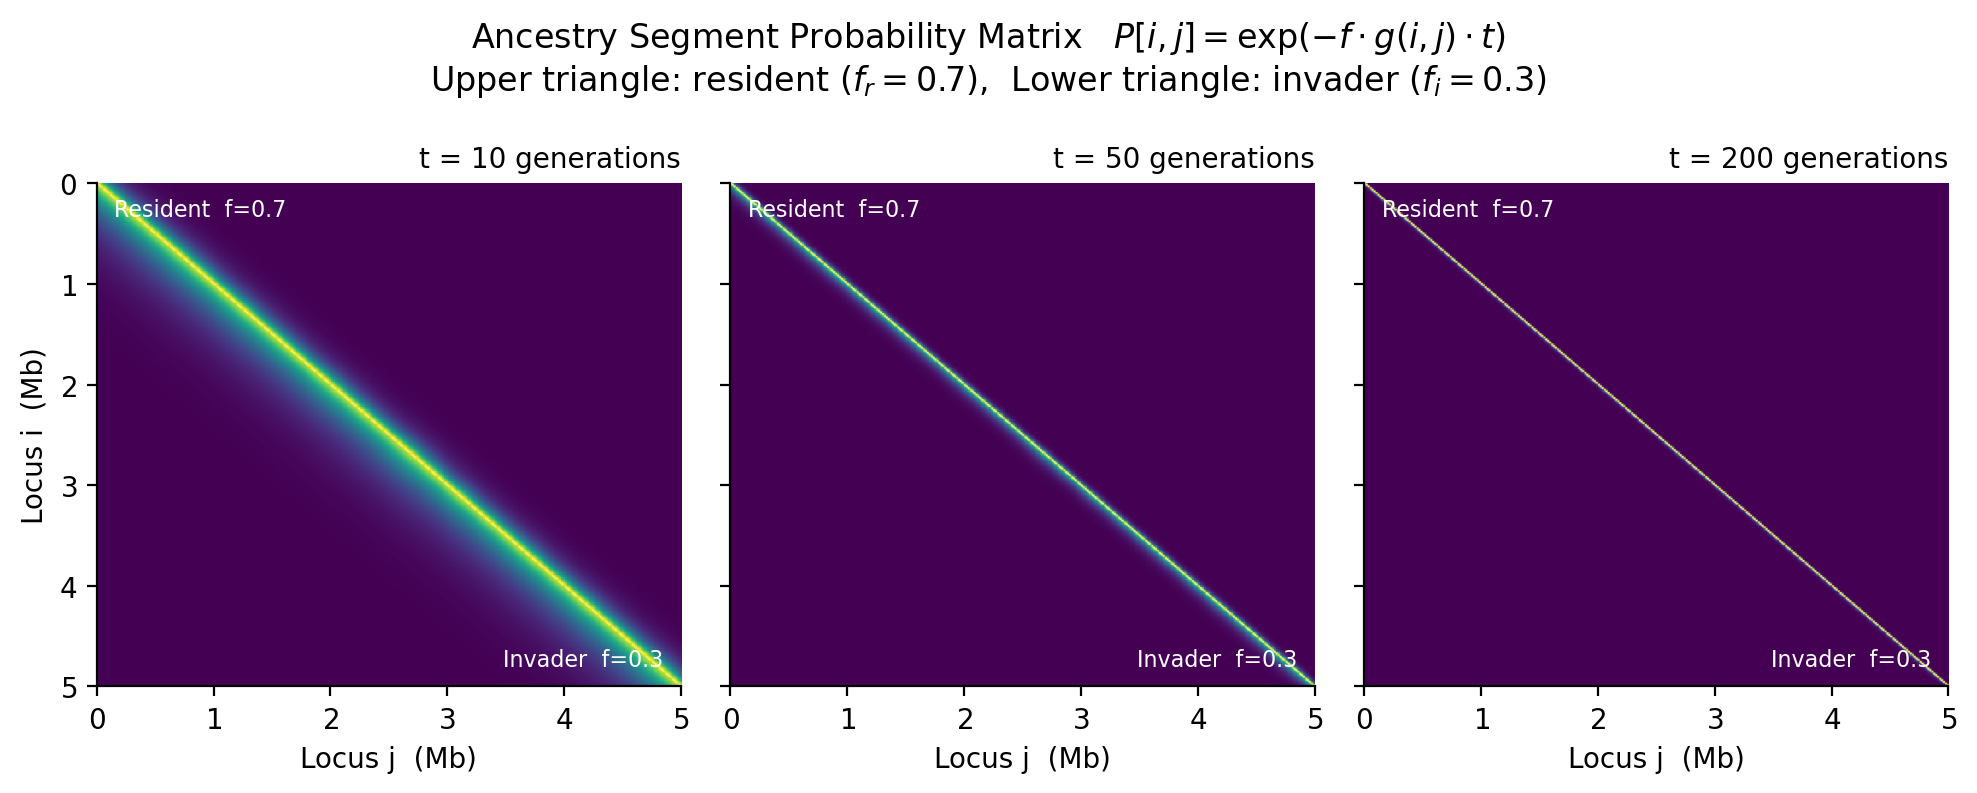

In [55]:
# ── Plot matrices for t = 10, 50, 200 ───────────────────────────────────────
# Use a subset of map points for speed; full resolution not needed for display
n_sub     = 300
sub_idx   = np.linspace(0, N_MAP_POINTS - 1, n_sub, dtype=int)
gpos_sub  = genetic_map[sub_idx]
phys_sub  = physical_map[sub_idx]

t_values  = [10, 50, 200]

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
# fig = plt.figure(figsize=(15, 5.5))
# gs  = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.06], wspace=0.12)
# axes = [fig.add_subplot(gs[i]) for i in range(3)]
# cax  = fig.add_subplot(gs[3])

for ax, t_val in zip(axes, t_values):
    P  = ancestry_segment_probability_matrix(gpos_sub, t_val, F_RES, F_INV)
    mb = phys_sub / 1e6

    im = ax.imshow(P, origin='upper', aspect='auto', cmap='viridis',
                   vmin=0, vmax=1,
                   extent=[mb[0], mb[-1], mb[-1], mb[0]])

    # Diagonal reference
    ax.plot([mb[0], mb[-1]], [mb[0], mb[-1]],
            color='white', lw=0.6, alpha=0.4, ls='--')

    ax.text(0.97, 0.03, f'Invader  f={F_INV}', transform=ax.transAxes,
            color='white', fontsize=8, ha='right', va='bottom')
    ax.text(0.03, 0.97, f'Resident  f={F_RES}', transform=ax.transAxes,
            color='white', fontsize=8, ha='left', va='top')

    ax.set_title(f't = {t_val} generations')
    ax.set_xlabel('Locus j  (Mb)')


axes[0].set_ylabel('Locus i  (Mb)')
for ax in axes[1:]:
    ax.set_yticklabels([])

# cb = fig.colorbar(im, cax=cax)
# cb.set_label('P[i, j]')
fig.suptitle(
    r'Ancestry Segment Probability Matrix   $P[i,j] = \exp(-f \cdot g(i,j) \cdot t)$'
    '\nUpper triangle: resident ($f_r=0.7$),  Lower triangle: invader ($f_i=0.3$)')

plt.tight_layout()
plt.savefig('ancestry_segment_matrix.png', dpi=150,
            bbox_inches='tight')
plt.show()


### 3.3 Reading the matrix

The colour at cell $(i, j)$ answers: *"Given that a tract of this ancestry starts
at locus $i$, what is the probability it extends at least as far as locus $j$?"*

Key observations:
- **Bright ridge along the diagonal**: all tracts start with probability 1 at zero length.
- **Faster decay with larger $t$**: at $t=200$ (right panel) only very short tracts
  are probable; the matrix is nearly zero away from the diagonal.
- **Asymmetry between triangles**: the upper triangle (resident, $f=0.7$) decays faster
  per unit genetic distance than the lower triangle (invader, $f=0.3$).


---
<a id="section-4"></a>
## 4 · Chromosome Simulation

### 4.1 Tract length distribution

Under the admixture model, segments sampled at generation $t$ have physical lengths:

$$L \sim \text{Exponential}\!\left(\lambda = r \cdot f \cdot t\right) \quad \text{(bp)}$$

The rate $\lambda$ combines:
- $r$: local recombination rate (converts genetic to physical),
- $f$: frequency of the *other* ancestry (each recombination with probability $f$
  lands in a foreign background, ending the tract),
- $t$: time since admixture (more generations → shorter expected tracts).

Mean tract lengths:

| Ancestry | Formula | Value (this run) |
|----------|---------|-----------------|
| Resident | $1/(r \cdot f_i \cdot t)$ | $\approx 1/(r \cdot 0.3 \cdot t)$ |
| Invader  | $1/(r \cdot f_r \cdot t)$ | $\approx 1/(r \cdot 0.7 \cdot t)$ |

Note that **resident** tracts have rate $f_i \cdot t$ (broken by encounters with
foreign background) and **foreign** tracts have rate $f_r \cdot t$ (broken by
encounters with resident background).


In [56]:
def simulate_chromosome(chrom_len, r, f_res, f_inv, t, rng):
    """
    Simulate a single chromosome as alternating resident / foreign segments.

    Segment lengths ~ Exponential(rate = r * f_other * t) in base pairs,
    where f_other is the frequency of the opposite ancestry.

    Parameters
    ----------
    chrom_len : int    — chromosome length in bp
    r         : float  — mean recombination rate (Morgans/bp)
    f_res     : float  — resident ancestry frequency
    f_inv     : float  — invader  ancestry frequency
    t         : int    — generations since admixture
    rng       : numpy Generator

    Returns
    -------
    list of (start, end, ancestry) tuples covering [0, chrom_len]
    """
    segs    = []
    pos     = 0
    current = rng.choice(['resident', 'foreign'])

    while pos < chrom_len:
        # Rate of ending: other-ancestry frequency * recombination rate * time
        f      = f_res if current == 'resident' else f_inv
        length = max(1, int(rng.exponential(1.0 / (r * f * t))))
        end    = min(pos + length, chrom_len)
        segs.append((pos, end, current))
        pos     = end
        current = 'foreign' if current == 'resident' else 'resident'

    return segs


rng    = np.random.default_rng(7)
chroms = [simulate_chromosome(CHROM_LENGTH, r, F_RES, F_INV, T, rng)
          for _ in range(N_CHROMOSOMES)]

# Summary statistics
print(f"{'Chr':>4}  {'#res':>5}  {'res bp':>9}  {'#inv':>5}  {'inv bp':>9}  {'total':>9}")
print('-' * 55)
for i, ch in enumerate(chroms):
    nr  = sum(1 for s in ch if s[2] == 'resident')
    ni  = sum(1 for s in ch if s[2] == 'foreign')
    rbp = sum(e-s for s,e,a in ch if a == 'resident')
    ibp = sum(e-s for s,e,a in ch if a == 'foreign')
    print(f"{i+1:>4}  {nr:>5}  {rbp/1e3:>8.0f}k  {ni:>5}  {ibp/1e3:>8.0f}k  "
          f"{(rbp+ibp)/1e3:>8.0f}k")


 Chr   #res     res bp   #inv     inv bp      total
-------------------------------------------------------
   1    131      1470k    132      3530k      5000k
   2    125      1689k    125      3311k      5000k
   3    141      1508k    141      3492k      5000k
   4    144      1495k    144      3505k      5000k
   5    119      1368k    119      3632k      5000k
   6    130      1448k    131      3552k      5000k
   7    126      1463k    127      3537k      5000k
   8    135      1622k    136      3378k      5000k
   9    134      1557k    134      3443k      5000k
  10    141      1623k    141      3377k      5000k


In [57]:
def inject_segment(segs, s0, e0, ancestry):
    """Replace all segments in [s0, e0) with a single segment of given ancestry."""
    new = []
    for (s, e, a) in segs:
        if e <= s0 or s >= e0:
            new.append((s, e, a))
        else:
            if s < s0: new.append((s, s0, a))
            if e > e0: new.append((e0, e, a))
    new.append((s0, e0, ancestry))
    new.sort()
    return new

# chroms[0] = inject_segment(chroms[0], 1_800_000, 3_600_000, 'foreign')    # 1.8 Mb
# chroms[3] = inject_segment(chroms[3],   400_000, 2_000_000, 'resident')   # 1.6 Mb

# for c in range(N_CHROMOSOMES-1):
#     chroms[c] = inject_segment(chroms[c], 1_800_000-c*50000, 2_200_000+c*50000, 'foreign')  

mean_res = 1 / (r * F_INV * T)   # resident tracts end when recomb. hits foreign bg
mean_inv = 1 / (r * F_RES * T)


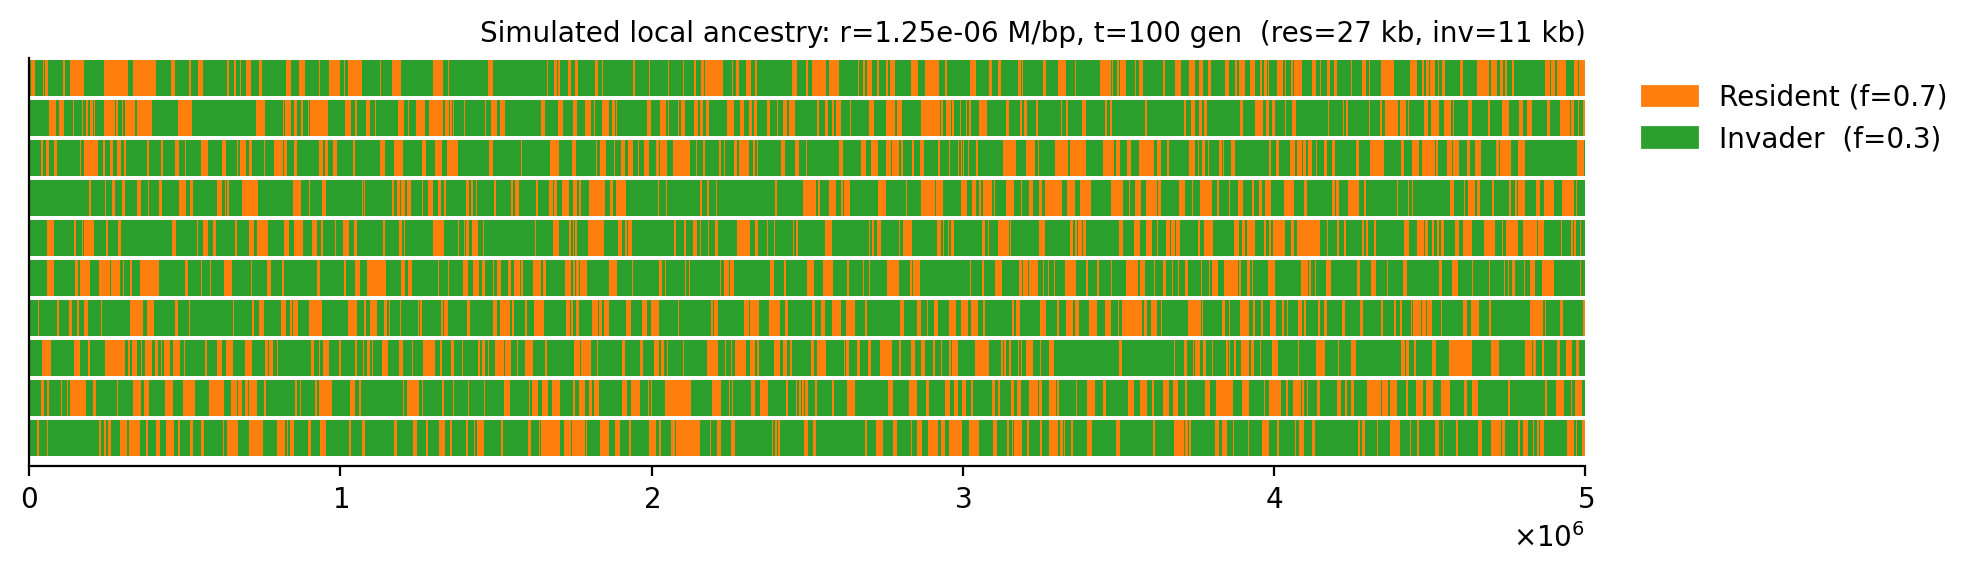

In [58]:
# ── Plot chromosome diagram ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3))

for i, ch in enumerate(chroms):
    for (s, e, anc) in ch:
        ax.barh(i-0.5, e-s, left=s, height=0.9,
                color=COLOR[anc], linewidth=0)

ax.set_xlim(0, CHROM_LENGTH)
ax.set_ylim(-1.2, N_CHROMOSOMES - 1)
ax.set_yticks([])

patches = [mpatches.Patch(color=COLOR['resident'], label=f'Resident (f={F_RES})'),
           mpatches.Patch(color=COLOR['foreign'],  label=f'Invader  (f={F_INV})')]
ax.legend(handles=patches, bbox_to_anchor=(1.02, 1))
ax.set_title(
    f'Simulated local ancestry: r={r:.2e} M/bp, t={T} gen  (res={mean_res/1e3:.0f} kb, inv={mean_inv/1e3:.0f} kb)')

plt.tight_layout()
plt.savefig('chromosome_diagram.png', dpi=150, bbox_inches='tight')
plt.show()


---
<a id="section-5"></a>
## 5 · Per-Position Mean Probability

### 5.1 Definition

For each evaluation position $x$ along the chromosome, we compute:

$$\bar{P}_f(x) = \frac{1}{|C_f(x)|} \sum_{c \in C_f(x)} \exp\!\left(-f \cdot g_c(x) \cdot t\right)$$

where:
- $C_f(x)$ is the set of chromosomes on which position $x$ falls in an ancestry-$f$ segment,
- $g_c(x)$ is the genetic length (Morgans) of the segment covering position $x$ on chromosome $c$,
- $f$ is the frequency of the opposite ancestry (the rate parameter).

### 5.2 Interpretation

$\bar{P}_f(x)$ is the **average probability** (across chromosomes) that a segment
of the observed length, spanning position $x$, arises by chance under the null
exponential model.

- Values near 1: short segments — unremarkable.
- Values near $e^{-1} \approx 0.37$: segments at the expected mean length.
- Values near 0: segments much longer than the null expectation — suspicious.

Importantly, $\bar{P}_f(x)$ aggregates over chromosomes by averaging, not by
multiplying. The significance of individual segments is addressed in Section 6.


In [59]:
eval_pos = np.linspace(0, CHROM_LENGTH, N_EVAL)

# Accumulate probability and count per position per ancestry
prob_sum = {a: np.zeros(N_EVAL) for a in ('resident', 'foreign', 'both')}
# prob_prod = {a: np.ones(N_EVAL) for a in ('resident', 'foreign', 'both')}
count    = {a: np.zeros(N_EVAL) for a in ('resident', 'foreign', 'both')}

for ch in chroms:
    for (start, end, anc) in ch:
        f    = F_RES if anc == 'resident' else F_INV
        g    = float(phys_to_gen(end) - phys_to_gen(start))   # Morgans
        prob = np.exp(-f * g * T)                              # p-value / probability
        mask = (eval_pos >= start) & (eval_pos < end)
        prob_sum[anc][mask] += prob
        # prob_prod[anc][mask] *= prob
        count[anc][mask]    += 1

        prob_sum['both'][mask] += prob
        # prob_prod['both'][mask] *= prob
        count['both'][mask] += 1


mean_prob = {
    # a: np.where(count[a] > 0, prob_sum[a] / count[a], np.nan) for a in ('resident', 'foreign', 'both')
    a: np.where(count[a] > 0, -np.log10(prob_sum[a] / count[a]), np.nan) for a in ('resident', 'foreign', 'both')
    # a: np.where(count[a] > 0, -np.log10(prob_prod[a]), np.nan) for a in ('resident', 'foreign', 'both')
}
mean_prob

/var/folders/s6/srs8qkh52w1_h32d65z95tth0000gn/T/ipykernel_54031/2357159454.py:25: RuntimeWarning: invalid value encountered in divide
  a: np.where(count[a] > 0, -np.log10(prob_sum[a] / count[a]), np.nan) for a in ('resident', 'foreign', 'both')


{'resident': array([0.06576095, 0.07303125,        nan, ..., 0.30680023, 0.2937375 ,
               nan], shape=(3000,)),
 'foreign': array([0.56630584, 0.59606424, 0.6001738 , ..., 0.23811788, 0.20451265,
               nan], shape=(3000,)),
 'both': array([0.40998403, 0.50494208, 0.6001738 , ..., 0.26430229, 0.22940966,
               nan], shape=(3000,))}

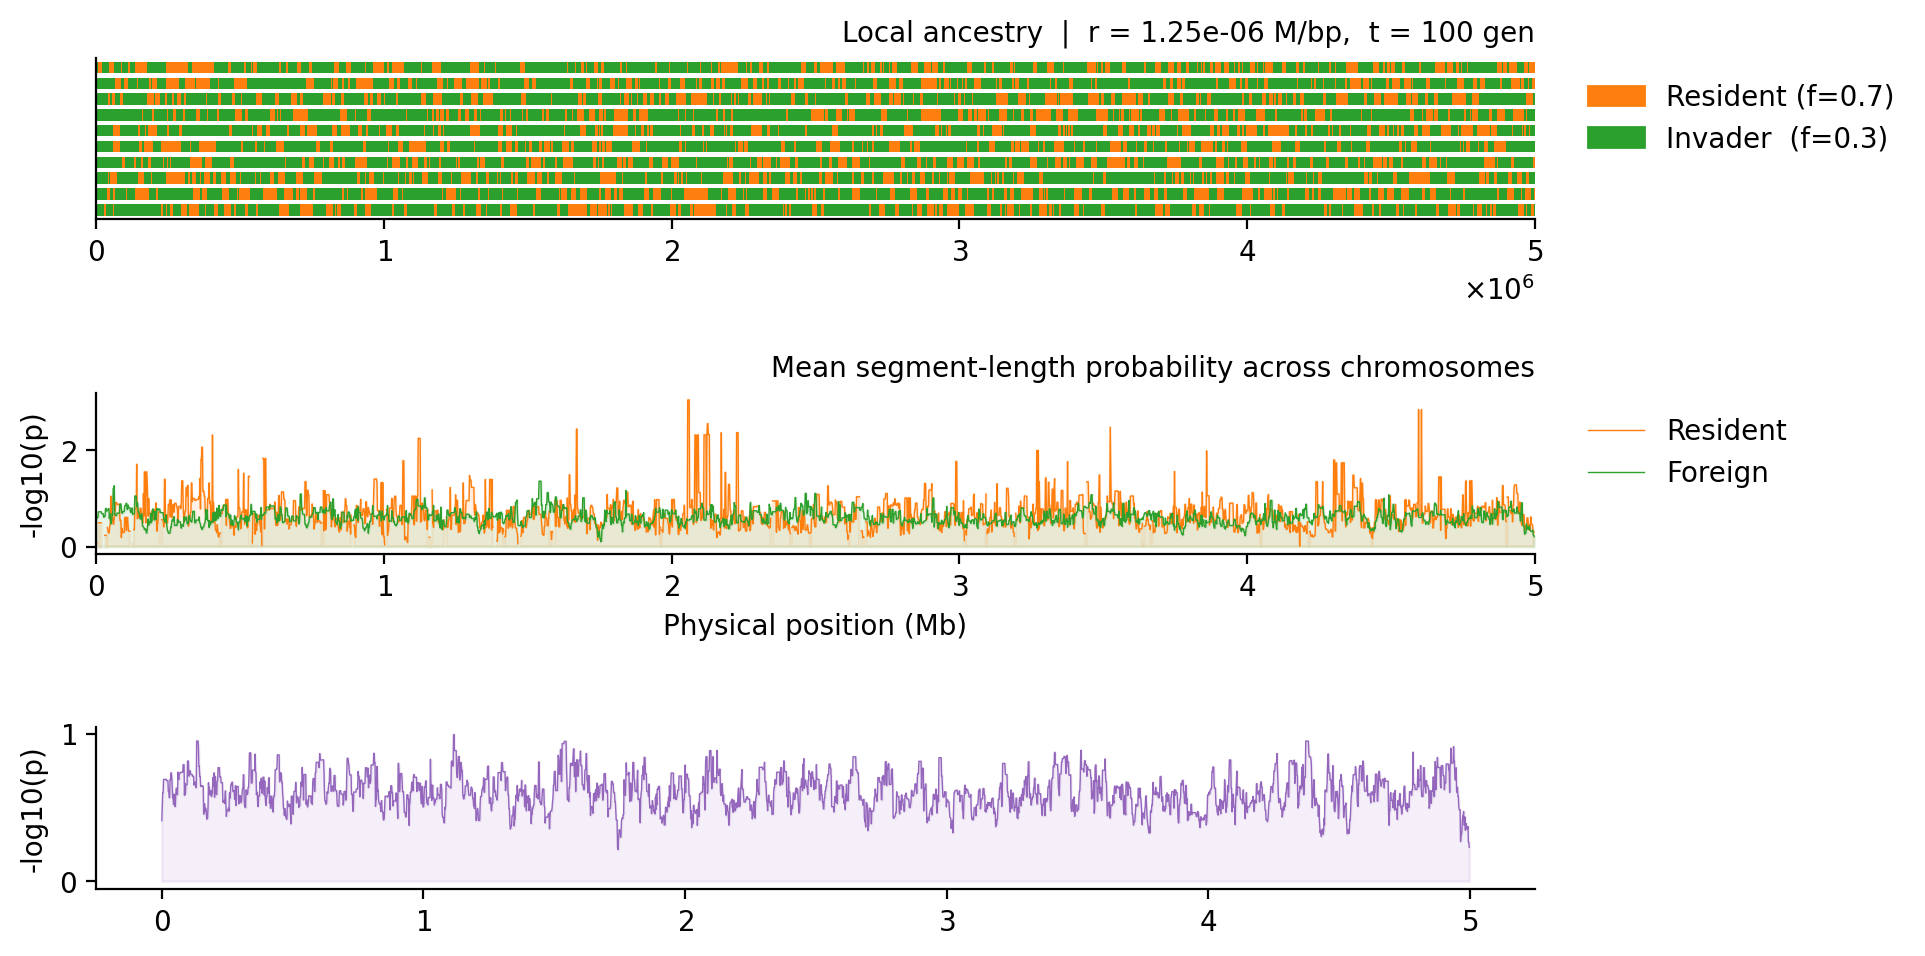

In [60]:
# ── Plot per-position mean probability ──────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(10, 5))

# Chromosome diagram (compact)
ax1 = axes[0]
for i, ch in enumerate(chroms):
    for (s, e, anc) in ch:
        ax1.barh(i, e-s, left=s, height=0.72,
                 color=COLOR[anc], linewidth=0)
ax1.set_xlim(0, CHROM_LENGTH); ax1.set_ylim(-0.6, N_CHROMOSOMES - 0.4)
ax1.set_yticks([])

patches = [mpatches.Patch(color=COLOR['resident'], label=f'Resident (f={F_RES})'),
           mpatches.Patch(color=COLOR['foreign'],  label=f'Invader  (f={F_INV})')]
ax1.legend(handles=patches, bbox_to_anchor=(1.02, 1))
ax1.set_title(f'Local ancestry  |  r = {r:.2e} M/bp,  t = {T} gen')

# Mean probability
ax2 = axes[1]
mb  = eval_pos / 1e6

for anc in ('resident', 'foreign'):
    ax2.plot(mb, mean_prob[anc], color=COLOR[anc], lw=0.5,
             label=f'{anc.capitalize()}')
    ax2.fill_between(mb, mean_prob[anc], alpha=0.10, color=COLOR[anc])

ax2.set_xlim(0, CHROM_LENGTH/1e6)
ax2.set_xlabel('Physical position (Mb)')
ax2.set_ylabel('-log10(p)')
ax2.legend(bbox_to_anchor=(1.02, 1))
ax2.set_title('Mean segment-length probability across chromosomes')

ax3 = axes[2]
anc='both'
ax3.plot(mb, mean_prob[anc], color=COLOR[anc], lw=0.5,
            label=f'{anc.capitalize()}')
ax3.fill_between(mb, mean_prob[anc], alpha=0.10, color=COLOR[anc])
ax3.set_ylabel('-log10(p)')


plt.tight_layout(pad=1.5)
plt.savefig('mean_probability_profile.png', dpi=150,
            bbox_inches='tight')
plt.show()


---
<a id="section-6"></a>
## 6 · Significance Testing

### 6.1 Null hypothesis and test statistic

For each position $x$, we take the **minimum p-value** (= longest segment) across
all chromosomes:

$$p_f(x) = \min_{c \in C_f(x)} \exp\!\left(-f \cdot t \cdot g_c(x)\right)$$

This is a natural choice: we are asking whether *any* chromosome carries an
unexpectedly long tract at this position.

### 6.2 The multiple testing problem

We evaluate significance at $N = 3{,}000$ positions along the chromosome. If we
naively declare every position with $p < 0.05$ as significant, we expect
$0.05 \times 3{,}000 = 150$ **false positives** even when the null hypothesis
is true everywhere. This is the classical multiple testing problem: more tests
means more opportunities for chance events to masquerade as real signals.

Two standard corrections address this, differing in **what they control**:

#### Bonferroni correction — controlling the Family-Wise Error Rate (FWER)

$$p^{\text{Bonf}}_f(x) = \min\!\left(1,\ p_f(x) \cdot N\right)$$

Bonferroni asks: *"What is the probability that **any** of the $N$ tests produces
a false positive?"* It ensures this probability stays below $\alpha$ by demanding
that each individual test pass a threshold of $\alpha / N$. This is very strict —
it treats every test as an independent chance to make an error, so the threshold
shrinks linearly with the number of tests.

**When to use it:** when even a single false positive is unacceptable (e.g. confirming
a specific candidate region). The price is low sensitivity — many real signals will
be missed.

#### Benjamini–Hochberg correction — controlling the False Discovery Rate (FDR)

The BH procedure controls a different quantity: among all the positions we *declare*
significant, what **fraction** are false positives? Specifically, it guarantees
$\text{FDR} = E[\text{false positives} / \text{total discoveries}] \leq \alpha$.

The procedure works as a **step-up algorithm**:

1. **Sort** all $N$ p-values from smallest to largest: $p_{(1)} \leq p_{(2)} \leq \cdots \leq p_{(N)}$.
2. **Assign thresholds**: position $k$ in the sorted list gets threshold $k \cdot \alpha / N$.
3. **Find the cutoff**: identify the largest rank $k^*$ such that $p_{(k^*)} \leq k^* \cdot \alpha / N$.
4. **Declare significant**: all positions with rank $\leq k^*$ (i.e. all p-values $\leq p_{(k^*)}$).

The adjusted p-value for rank $k$ is:

$$p^{\text{BH}}_{(k)} = \min_{j \geq k} \frac{p_{(j)} \cdot N}{j}$$

**Intuition:** the more true signals there are in the data, the more the sorted
p-values "pull away" from the uniform distribution expected under the null. The BH
procedure exploits this: when many small p-values cluster at the bottom of the sorted
list, the step-up threshold becomes more generous, allowing more discoveries while
still controlling the false discovery proportion.

**Why BH finds far more significant positions than Bonferroni in this dataset:**
We injected anomalous segments into all 10 chromosomes in the 1.5–3 Mb region, creating
many genuinely significant positions. BH adapts to this abundance of true signals and
sets a less stringent effective threshold, recovering most of them. Bonferroni ignores
the number of true signals entirely — its threshold is fixed at $\alpha / N$ regardless.

### 6.3 Joint test across both ancestries

Sometimes we want to know whether a genomic region is unusual in **both** ancestry
classes simultaneously. This could indicate:
- A **recombination cold spot** (both ancestry types retain long tracts because
  recombination is suppressed),
- A **selective sweep** acting on the local haplotype regardless of ancestry background.

Testing each ancestry separately and requiring both to be significant is overly
conservative. Instead, **Fisher's method** provides a principled way to combine
the evidence from both tests into one.

**How it works (intuitively):** each p-value is converted into a "surprise score"
$-2 \ln p$. A very small p-value produces a large surprise; a p-value near 1
produces a score near 0. Fisher's method adds the surprise scores from the two
ancestry tests:

$$X^2 = -2\left(\ln p_r + \ln p_i\right)$$

Under the null hypothesis (both p-values are uniform), this sum follows a
$\chi^2(4)$ distribution. The combined p-value is $P(\chi^2(4) \geq X^2)$.

The $\chi^2(4)$ null arises because:
- Each $-2 \ln p$ has a $\chi^2(2)$ distribution when $p \sim \text{Uniform}[0,1]$
  under $H_0$ (which holds here since $p = \exp(-\lambda G)$ with $G \sim \text{Exp}(\lambda)$).
- The sum of two independent $\chi^2(2)$ variables is $\chi^2(4)$.

The resulting p-value is then BH-adjusted for multiple testing across positions.

**Key property:** Fisher's method is sensitive to cases where *both* p-values are
small, not just one. A position where only one ancestry is anomalous will not produce
a significant joint test unless the signal is extreme.

### 6.4 Why the Bonferroni threshold is demanding

The threshold for Bonferroni significance (raw p $< \alpha/N$) requires:

$$g > \frac{-\ln(\alpha/N)}{f \cdot t}$$

Plugging in $\alpha=0.05$, $N=3000$, $f=0.7$, $t=100$:

$$g > \frac{-\ln(1.67 \times 10^{-5})}{0.7 \times 100} \approx 0.157 \text{ Morgans}$$

Converting to physical distance: $0.157 / r \approx 1.2$ Mb. 
This is $\approx 11 \times$ the mean resident tract length — i.e., Bonferroni
significance demands an extreme outlier, which is appropriate for a one-sided test
for unusually *long* tracts.

In [61]:
# ── Per-position p-values: minimum and per-chromosome matrix ─────────────────
pval = {a: np.full(N_EVAL, np.nan) for a in ('resident', 'foreign')}

# Per-chromosome p-value matrix: pval_matrix[anc][position, chromosome]
pval_matrix = {a: np.full((N_EVAL, N_CHROMOSOMES), np.nan) for a in ('resident', 'foreign')}

for ci, ch in enumerate(chroms):
    for (start, end, anc) in ch:
        f    = F_RES if anc == 'resident' else F_INV
        g    = float(phys_to_gen(end) - phys_to_gen(start))
        p    = np.exp(-f * T * g)           # p-value = survival function
        mask = (eval_pos >= start) & (eval_pos < end)
        # Min p-value across chromosomes (existing test)
        cur  = pval[anc][mask]
        pval[anc][mask] = np.where(np.isnan(cur), p, np.minimum(cur, p))
        # Per-chromosome matrix (new)
        pval_matrix[anc][mask, ci] = p

# ── Multiple-testing corrections ────────────────────────────────────────────
def bh_correction(pvals_flat):
    """
    Benjamini–Hochberg FDR correction.
    NaN entries are preserved. Returns adjusted p-values (same shape).
    """
    adj   = np.full_like(pvals_flat, np.nan)
    valid = ~np.isnan(pvals_flat)
    p     = pvals_flat[valid]
    n     = len(p)
    order    = np.argsort(p)
    p_sorted = p[order]
    rank     = np.arange(1, n + 1, dtype=float)
    # Adjusted p in sorted order: p * N / rank, capped at 1
    adj_sorted = np.minimum(1.0, p_sorted * n / rank)
    # Monotonise from largest rank down (ensure non-increasing adjusted p)
    adj_sorted = np.minimum.accumulate(adj_sorted[::-1])[::-1]
    # Map back to original positions
    adj_orig = np.empty(n)
    adj_orig[order] = adj_sorted
    adj[valid] = adj_orig
    return adj

pval_bonf = {a: np.minimum(1.0, pval[a] * N_EVAL)  for a in ('resident', 'foreign')}
pval_bh   = {a: bh_correction(pval[a])              for a in ('resident', 'foreign')}

# ── Fisher joint test (across ancestries, using min-p per ancestry) ──────────
eps   = 1e-300
lp_r  = np.where(np.isnan(pval['resident']), 0., np.log(np.maximum(pval['resident'], eps)))
lp_i  = np.where(np.isnan(pval['foreign']),  0., np.log(np.maximum(pval['foreign'],  eps)))
both  = ~np.isnan(pval['resident']) & ~np.isnan(pval['foreign'])
fs    = np.where(both, -2*(lp_r + lp_i), np.nan)
fp    = np.where(both, 1 - chi2.cdf(fs, df=4), np.nan)
fp_bh = bh_correction(fp)

# ── Summary ──────────────────────────────────────────────────────────────────
bonf_threshold_raw = ALPHA / N_EVAL
print(f"Bonferroni threshold (raw p < {bonf_threshold_raw:.2e})")
print()
print(f"  {'':8s}  {'Raw':>12s}  {'Bonferroni':>12s}  {'BH-FDR':>12s}")
print(f"  {'':8s}  {'(p < α)':>12s}  {'(FWER < α)':>12s}  {'(FDR < α)':>12s}")
print('  ' + '-' * 52)
for a in ('resident', 'foreign'):
    n_raw  = int(np.nansum(pval[a] < ALPHA))
    n_bonf = int(np.nansum(pval_bonf[a] < ALPHA))
    n_bh   = int(np.nansum(pval_bh[a]   < ALPHA))
    print(f"  {a:8s}  {n_raw:>12d}  {n_bonf:>12d}  {n_bh:>12d}")
n_raw_j  = int(np.nansum(fp < ALPHA))
n_bh_j   = int(np.nansum(fp_bh < ALPHA))
print(f"  {'joint':8s}  {n_raw_j:>12d}  {'—':>12s}  {n_bh_j:>12d}")
print()
print("Note: Raw > BH-FDR > Bonferroni — corrections can only remove significance, never add it.")

Bonferroni threshold (raw p < 1.67e-05)

                     Raw    Bonferroni        BH-FDR
                 (p < α)    (FWER < α)     (FDR < α)
  ----------------------------------------------------
  resident          1409             0           368
  foreign           2294             0          1995
  joint             2598             —          2555

Note: Raw > BH-FDR > Bonferroni — corrections can only remove significance, never add it.


### 6.5 Combined test across chromosomes with effective sample size

The min-p test (Section 6.1) uses only the **single longest** segment at each position.
A natural extension is to combine evidence from **all** chromosomes using Fisher's
method:

$$F_a(x) = -2 \sum_{c=1}^{k} \ln p_{a,c}(x)$$

where $p_{a,c}(x)$ is the p-value of the segment covering position $x$ on chromosome
$c$ with ancestry $a$, and $k$ is the number of chromosomes carrying that ancestry
at $x$.

#### The independence problem

Under independence, $F_a(x) \sim \chi^2(2k)$. But chromosomes in a sample are
**not independent** — they share genealogical history through their coalescent tree.
Segments at the same genomic position on different chromosomes are correlated: if two
chromosomes coalesce recently, they tend to carry similar segment lengths. Using
$\chi^2(2k)$ as the null would be **anti-conservative** (too many false positives).

#### Effective sample size correction

To account for correlation, we estimate an **effective number of independent
chromosomes** $k_{\text{eff}} \leq k$ from the data. We use the
[Li and Ji (2005)](https://doi.org/10.1038/sj.hdy.6800717) formula based on the
correlation matrix $R$ of log-p-values across chromosomes:

$$k_{\text{eff}} = \frac{k^2}{\|R\|_F^2} = \frac{k^2}{\sum_{i,j} r_{ij}^2}$$

where $\|R\|_F$ is the Frobenius norm. When chromosomes are fully independent,
$R = I$ and $k_{\text{eff}} = k$. When they are perfectly correlated, $R$ is all-ones
and $k_{\text{eff}} = 1$.

**Estimating correlation under the null.** A critical subtlety: $k_{\text{eff}}$
should reflect the genealogical (background) correlation between chromosomes, not
correlation induced by the signal itself. If we include positions where all chromosomes
carry injected segments, the correlation estimate is inflated and $k_{\text{eff}}$
collapses — making the test less powerful than the min-p test. To avoid this, we
estimate $R$ using only the 80% of positions with the largest (least significant)
median p-values, which are likely to be under the null.

The corrected test rescales the Fisher statistic to match the reduced degrees of freedom:

$$p_{\text{combined}}(x) = P\!\left(\chi^2(2 k_{\text{eff}}) \geq F_a(x) \cdot \frac{k_{\text{eff}}}{k}\right)$$

This test is more powerful than min-p when **multiple chromosomes carry moderately
long segments** at the same position — a pattern expected under selection that affects
many lineages but doesn't produce a single extreme outlier.

In [62]:
# ── Effective sample size and Fisher combined test across chromosomes ─────────

def effective_sample_size(pval_mat, signal_quantile=0.8):
    """
    Estimate k_eff from the correlation matrix of log-p-values across chromosomes,
    using only positions with moderate p-values (likely null) to avoid confounding
    the correlation estimate with signal-induced correlation.
    
    Uses the Li & Ji (2005) formula: k_eff = k^2 / ||R||_F^2.
    """
    lp = np.log(np.maximum(pval_mat, eps))
    valid_rows = ~np.any(np.isnan(lp), axis=1)
    lp_valid = lp[valid_rows]
    
    if lp_valid.shape[0] < 10:
        k = pval_mat.shape[1]
        return float(k), np.eye(k), 0
    
    # Filter to likely-null positions: those with moderate p-values
    median_lp = np.median(lp_valid, axis=1)
    threshold = np.quantile(median_lp, 1 - signal_quantile)
    null_mask = median_lp >= threshold
    lp_null = lp_valid[null_mask]
    
    n_used = lp_null.shape[0]
    
    R = np.corrcoef(lp_null.T)
    k = R.shape[0]
    frob_sq = np.sum(R ** 2)
    k_eff = k ** 2 / frob_sq
    return k_eff, R, n_used

# Compute k_eff for each ancestry
k_eff = {}
corr_mat = {}
for anc in ('resident', 'foreign'):
    k_eff[anc], corr_mat[anc], n_used = effective_sample_size(pval_matrix[anc])
    print(f"{anc.capitalize():8s}:  k = {N_CHROMOSOMES},  k_eff = {k_eff[anc]:.2f}  "
          f"(estimated from {n_used} null-like positions, "
          f"correlation reduces effective sample by {(1 - k_eff[anc]/N_CHROMOSOMES)*100:.0f}%)")

# ── Fisher combined statistic per position ───────────────────────────────────
# No cap on individual contributions: the k_eff correction accounts for 
# correlation, and capping would reduce power against genuine signals.
# We use chi2.sf for numerical stability.

pval_fisher_combined = {}
pval_fisher_combined_bh = {}

for anc in ('resident', 'foreign'):
    mat = pval_matrix[anc]
    lp  = -2 * np.log(np.maximum(mat, eps))
    n_chrom = np.sum(~np.isnan(mat), axis=1)
    fisher_stat = np.nansum(lp, axis=1)
    
    # Rescale: F_scaled = F * (k_eff / k)
    fisher_scaled = np.where(n_chrom > 0,
                             fisher_stat * k_eff[anc] / n_chrom,
                             np.nan)
    df = 2 * k_eff[anc]
    
    raw_p = np.where(n_chrom > 0,
                     chi2.sf(fisher_scaled, df=df),
                     np.nan)
    
    pval_fisher_combined[anc] = raw_p
    pval_fisher_combined_bh[anc] = bh_correction(raw_p)

# Summary
print()
print("Fisher combined test (all chromosomes, k_eff-corrected):")
print(f"  {'':8s}  {'Raw':>12s}  {'BH-FDR':>12s}")
print(f"  {'':8s}  {'(p < α)':>12s}  {'(FDR < α)':>12s}")
print('  ' + '-' * 36)
for anc in ('resident', 'foreign'):
    n_raw = int(np.nansum(pval_fisher_combined[anc] < ALPHA))
    n_bh  = int(np.nansum(pval_fisher_combined_bh[anc] < ALPHA))
    print(f"  {anc:8s}  {n_raw:>12d}  {n_bh:>12d}")
print()
for anc in ('resident', 'foreign'):
    p = pval_fisher_combined[anc]
    valid = ~np.isnan(p)
    print(f"  {anc:8s}:  min p = {np.min(p[valid]):.2e},  "
          f"max -log10(p) = {-np.log10(max(np.min(p[valid]), eps)):.1f}")

Resident:  k = 10,  k_eff = 10.00  (estimated from 0 null-like positions, correlation reduces effective sample by 0%)
Foreign :  k = 10,  k_eff = 6.86  (estimated from 76 null-like positions, correlation reduces effective sample by 31%)

Fisher combined test (all chromosomes, k_eff-corrected):
                     Raw        BH-FDR
                 (p < α)     (FDR < α)
  ------------------------------------
  resident          1934          1804
  foreign           2071          1694

  resident:  min p = 5.80e-20,  max -log10(p) = 19.2
  foreign :  min p = 7.23e-07,  max -log10(p) = 6.1


/var/folders/s6/srs8qkh52w1_h32d65z95tth0000gn/T/ipykernel_54031/1675815856.py:58: RuntimeWarning: invalid value encountered in divide
  fisher_stat * k_eff[anc] / n_chrom,


### 6.6 Reading the significance plot

The plot below has five panels, each showing the same 5 Mb chromosome on the x-axis:

**Panel 1 — Chromosome diagram** (reference).
The simulated ancestry segments across all 10 chromosomes, with injected anomalously
long foreign segments in the ~1.5–3 Mb region. This panel is included so you can
visually cross-reference which segments drive the signals below.

**Panel 2 — Raw p-values** ($-\log_{10}$ scale).
At each position $x$, we plot $-\log_{10}(p(x))$ where $p(x)$ is the minimum p-value
(longest segment) across all chromosomes at that position. Higher values = longer
tract = more surprising under the null model.
- The **dotted line** marks the naive $\alpha = 0.05$ threshold — almost everything
  exceeds this, illustrating why uncorrected testing is useless with 3,000 tests.
- The **dashed line** marks the Bonferroni threshold $\alpha / N$ ($-\log_{10} \approx 4.8$).
  Only the most extreme segments (the injected foreign tracts) cross this line.

**Panel 3 — BH-FDR adjusted p-values** ($-\log_{10}$ scale).
The same p-values after Benjamini–Hochberg correction. Shaded regions and coloured dots
mark positions declared significant at FDR < 0.05. Notice that:
- Significance is concentrated in the **~1.5–3 Mb injected region**, matching the
  raw p-value pattern from panel 2.
- BH recovers more significant positions than Bonferroni because the abundance of
  true signals in the injected region makes the adaptive BH threshold more generous.
- Values that saturate at high $-\log_{10}$ reflect the numerical floor
  (`eps = 1e-300` in the log computation).

**Panel 4 — Fisher joint test** ($-\log_{10}$ scale, BH-adjusted).
This panel highlights positions where **both** ancestries are simultaneously anomalous.
The test statistic $-2(\ln p_r + \ln p_i)$ is large only when both individual p-values
are small. Key features:
- The ~1.5–3 Mb region shows extreme significance because every chromosome carries
  an injected foreign segment there, *and* the displaced resident segments at the
  boundaries are also unusually long.
- Positions outside this region are mostly non-significant in the joint test, even if
  one ancestry alone showed a signal — this is the key feature of the joint test.

**Panel 5 — Fisher combined test across chromosomes** ($-\log_{10}$ scale, BH-adjusted).
Instead of taking the single longest segment (min-p), this panel combines evidence from
**all** chromosomes at each position using Fisher's method with the $k_{\text{eff}}$
correction. It is sensitive to positions where **many chromosomes** carry moderately
long segments, even if none is individually extreme.

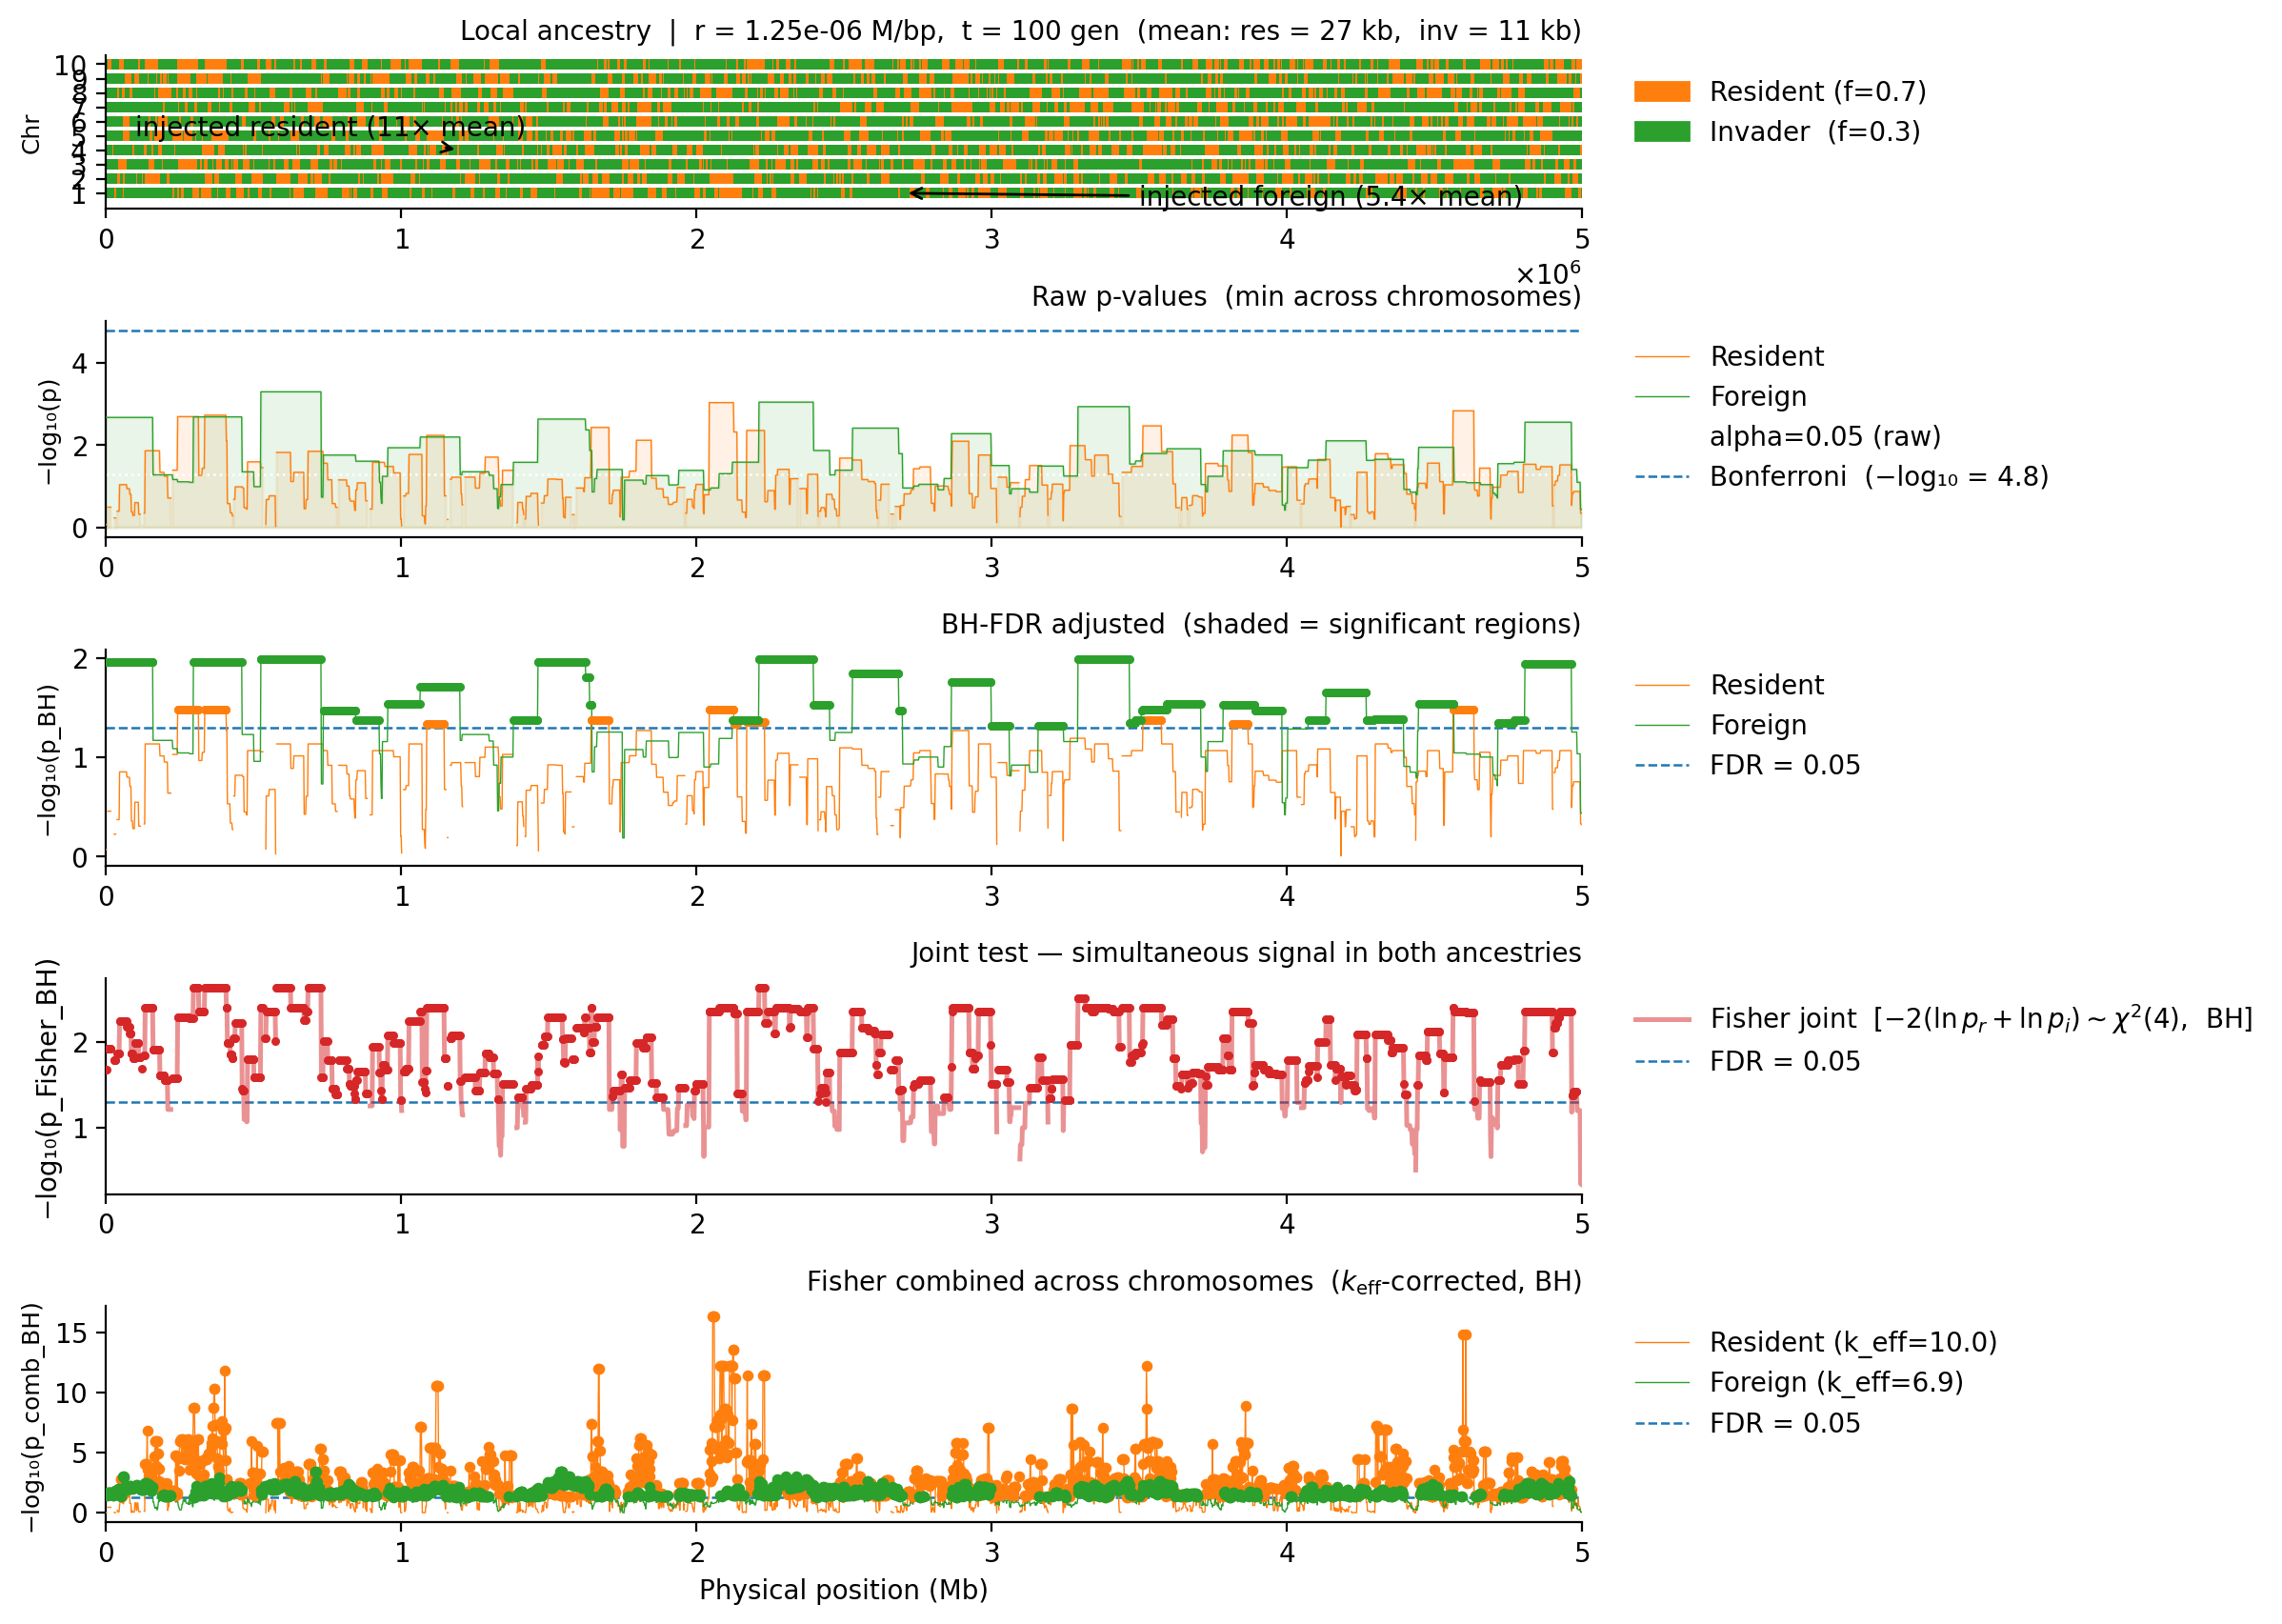

In [ ]:
# # ── Full significance plot ────────────────────────────────────────────────────
# def sig_shading(ax, pvals, alpha, color, alpha_fill=0.15):
#     """Shade contiguous significant regions."""
#     sig    = pvals < alpha
#     in_run = False
#     for k in range(len(sig)):
#         if sig[k] and not in_run:
#             x0 = mb[k]; in_run = True
#         if (not sig[k] or k == len(sig)-1) and in_run:
#             ax.axvspan(x0, mb[k], color=color, alpha=alpha_fill, zorder=0)
#             in_run = False

mb   = eval_pos / 1e6
bonf_line = -np.log10(ALPHA / N_EVAL)

fig = plt.figure(figsize=(10, 10))
gs  = gridspec.GridSpec(5, 1, hspace=0.55, height_ratios=[0.85, 1.2, 1.2, 1.2, 1.2])

# — Panel 1: chromosome diagram —
ax1 = fig.add_subplot(gs[0])
for i, ch in enumerate(chroms):
    for (s, e, anc) in ch:
        ax1.barh(i, e-s, left=s, height=0.72,
                 color=COLOR[anc], linewidth=0)
ax1.annotate('injected foreign (5.4× mean)', xy=(2.7e6, 0), xytext=(3.5e6, -0.85),
             arrowprops=dict(arrowstyle='->', lw=1.0))
ax1.annotate('injected resident (11× mean)', xy=(1.2e6, 3), xytext=(0.1e6, 4.0),
             arrowprops=dict(arrowstyle='->', lw=1.0))
ax1.set_xlim(0, CHROM_LENGTH); ax1.set_ylim(-1.1, N_CHROMOSOMES - 0.4)
ax1.set_yticks(range(N_CHROMOSOMES), [str(i+1) for i in range(N_CHROMOSOMES)])
ax1.set_ylabel('Chr', fontsize=9)
patches = [mpatches.Patch(color=COLOR['resident'], label=f'Resident (f={F_RES})'),
           mpatches.Patch(color=COLOR['foreign'],  label=f'Invader  (f={F_INV})')]
ax1.legend(handles=patches, bbox_to_anchor=(1.02, 1))
ax1.set_title(
    f'Local ancestry  |  r = {r:.2e} M/bp,  t = {T} gen  '
    f'(mean: res = {mean_res/1e3:.0f} kb,  inv = {mean_inv/1e3:.0f} kb)')

# — Panel 2: raw p-values —
ax2 = fig.add_subplot(gs[1])
for anc in ('resident', 'foreign'):
    y = -np.log10(np.maximum(pval[anc], eps))
    ax2.plot(mb, y, color=COLOR[anc], lw=0.5, label=anc.capitalize(), alpha=1, zorder=3)
    ax2.fill_between(mb, y, alpha=0.10, color=COLOR[anc])
ax2.axhline(-np.log10(ALPHA), color='white', lw=0.9, ls=':', label=f'alpha={ALPHA} (raw)')
ax2.axhline(bonf_line, lw=0.9, ls='--',
            label=f'Bonferroni  (−log₁₀ = {bonf_line:.1f})')
ax2.set_ylabel('−log₁₀(p)', fontsize=9)
ax2.set_title(r'Raw p-values  (min across chromosomes)')
ax2.legend(bbox_to_anchor=(1.02, 1))
ax2.set_xlim(0, CHROM_LENGTH/1e6)

# — Panel 3: BH-adjusted p-values —
ax3 = fig.add_subplot(gs[2])
for anc in ('resident', 'foreign'):
    y = -np.log10(np.maximum(pval_bh[anc], eps))
    ax3.plot(mb, y, color=COLOR[anc], lw=0.5, label=anc.capitalize(), zorder=3)
    # ax3.fill_between(mb, y, alpha=0.10, color=COLOR[anc])
    # sig_shading(ax3, pval_bh[anc], ALPHA, COLOR[anc])
    sig = pval_bh[anc] < ALPHA
    if sig.any():
        ax3.scatter(mb[sig], -np.log10(np.maximum(pval_bh[anc][sig], eps)),
                    color=COLOR[anc], s=5, zorder=5)
ax3.axhline(-np.log10(ALPHA), lw=0.9, ls='--',
            label=f'FDR = {ALPHA}')
ax3.set_ylabel('−log₁₀(p_BH)', fontsize=9)
ax3.set_title('BH-FDR adjusted  (shaded = significant regions)')
ax3.legend(bbox_to_anchor=(1.02, 1))
ax3.set_xlim(0, CHROM_LENGTH/1e6)

# — Panel 4: Fisher joint test (across ancestries) —
ax4 = fig.add_subplot(gs[3])
y = -np.log10(np.maximum(fp_bh, eps))
ax4.plot(mb, y, color=COLOR['joint'], lw=1.8,
         label=r'Fisher joint  [$-2(\ln p_r+\ln p_i)\sim\chi^2(4)$,  BH]', alpha=0.5, zorder=3)
# ax4.fill_between(mb, y, alpha=0.13, color=COLOR['joint'])
# sig_shading(ax4, fp_bh, ALPHA, COLOR['joint'])
sig_j = fp_bh < ALPHA
if sig_j.any():
    ax4.scatter(mb[sig_j], -np.log10(np.maximum(fp_bh[sig_j], eps)),
                color=COLOR['joint'], s=5, zorder=5)
ax4.axhline(-np.log10(ALPHA), lw=0.9, ls='--',
            label=f'FDR = {ALPHA}')
ax4.set_ylabel('−log₁₀(p_Fisher_BH)')
ax4.set_title('Joint test — simultaneous signal in both ancestries')
# ax4.yaxis.grid(True, lw=0.5, alpha=0.6)
ax4.legend(bbox_to_anchor=(1.02, 1))
ax4.set_xlim(0, CHROM_LENGTH/1e6)

# — Panel 5: Fisher combined test across chromosomes (k_eff-corrected) —
ax5 = fig.add_subplot(gs[4])
for anc in ('resident', 'foreign'):
    y = -np.log10(np.maximum(pval_fisher_combined_bh[anc], eps))
    ax5.plot(mb, y, color=COLOR[anc], lw=0.5, label=f'{anc.capitalize()} (k_eff={k_eff[anc]:.1f})', zorder=3)
    # ax5.fill_between(mb, y, alpha=0.10, color=COLOR[anc])
    # sig_shading(ax5, pval_fisher_combined_bh[anc], ALPHA, COLOR[anc])
    sig = pval_fisher_combined_bh[anc] < ALPHA
    if sig.any():
        ax5.scatter(mb[sig], -np.log10(np.maximum(pval_fisher_combined_bh[anc][sig], eps)),
                    color=COLOR[anc], s=10, zorder=5)
ax5.axhline(-np.log10(ALPHA), lw=0.9, ls='--',
            label=f'FDR = {ALPHA}')
ax5.set_ylabel('−log₁₀(p_comb_BH)', fontsize=9)
ax5.set_xlabel('Physical position (Mb)')
ax5.set_title(r'Fisher combined across chromosomes  ($k_{\mathrm{eff}}$-corrected, BH)')
ax5.legend(bbox_to_anchor=(1.02, 1))
ax5.set_xlim(0, CHROM_LENGTH/1e6)

# plt.savefig('local_ancestry_significance.png', dpi=150,
#             bbox_inches='tight')
plt.show()

### 6.7 Key takeaways

1. **Bonferroni is conservative by design.** It controls the probability of *any* false
   positive across all 3,000 tests. This makes it reliable for confirming individual
   candidate regions, but it misses many true signals — a tract must be ~11× the expected
   mean length to pass.

2. **BH-FDR adapts to the signal density.** When many positions are truly significant
   (as in the injected region), BH raises its effective threshold and recovers more
   true discoveries than Bonferroni. The trade-off: a small, controlled fraction
   of these discoveries (up to 5%) may be false positives.

3. **The Fisher joint test isolates co-occurring signals.** It highlights the ~1.5–3 Mb
   region where *both* ancestries carry anomalously long tracts on the same chromosomes.
   This is a stronger statement than either single-ancestry test alone — it points to a
   shared cause (here, the injected segments; in real data, possibly suppressed
   recombination or selection).

4. **The combined test across chromosomes uses all the data.** By summing evidence from
   all chromosomes (not just the most extreme one), the Fisher combined test with
   $k_{\text{eff}}$ correction can detect regions where many chromosomes are
   *moderately* affected. The effective sample size correction prevents inflated
   significance from genealogical correlations between chromosomes.

5. **Numerical saturation.** Extremely high $-\log_{10}$ values arise because
   the test statistics far exceed what the null distribution can produce at any
   meaningful probability. The code clamps p-values at `eps = 1e-300` to avoid
   log-of-zero errors. In practice, these values simply mean "overwhelmingly significant."

---
## 7 · Summary Table

| Step | Formula | Purpose |
|------|---------|---------|
| Tract length distribution | $L \sim \text{Exp}(r \cdot f_\text{other} \cdot t)$ | Null model for segment lengths |
| Probability matrix | $P[i,j] = \exp(-f \cdot \|g_j - g_i\| \cdot t)$ | Probability of a tract spanning $i$ to $j$ |
| p-value per position (min-p) | $p(x) = \min_c \exp(-f \cdot t \cdot g_c(x))$ | One-sided test for unusually long tracts |
| Bonferroni correction | $p^\text{Bonf} = \min(1,\ p \cdot N)$ | Controls family-wise error rate |
| BH-FDR correction | $p^\text{BH}_{(k)} = \min_{j \geq k} p_{(j)} N / j$ | Controls false discovery rate |
| Fisher joint test | $X^2 = -2(\ln p_r + \ln p_i) \sim \chi^2(4)$ | Detects anomalies in both ancestries simultaneously |
| Fisher combined ($k_\text{eff}$) | $F = -2\sum_c \ln p_c$, scaled by $k_\text{eff}/k$ | Combines all chromosomes, correcting for genealogical correlation |

### Key parameter relationships

$$\text{Bonferroni threshold} \Leftrightarrow g > \frac{-\ln(\alpha/N)}{f \cdot t}
  \approx \frac{11}{f \cdot t} \text{ Morgans (for } \alpha=0.05, N=3000\text{)}$$

$$\text{Mean tract length} = \frac{1}{f_\text{other} \cdot t} \text{ Morgans}
  = \frac{1}{r \cdot f_\text{other} \cdot t} \text{ bp}$$

A Bonferroni-significant tract must therefore be approximately **11× the mean length**,
regardless of the specific parameter values. The BH-FDR threshold is substantially
less stringent when many true signals are present.

In [15]:
# ── Threshold summary table ──────────────────────────────────────────────────
rows = []
for label, f, f_other in [('Resident', F_RES, F_INV), ('Invader', F_INV, F_RES)]:
    mean_g  = 1 / (f_other * T)              # Morgans
    mean_bp = mean_g / r
    g_bonf  = -np.log(ALPHA / N_EVAL) / (f_other * T)
    bp_bonf = g_bonf / r
    rows.append({
        'Ancestry'              : label,
        'f'                     : f,
        'f_other'               : f_other,
        'Rate λ = f_other·t'    : f'{f_other*T:.1f}  M⁻¹',
        'Mean tract (cM)'       : f'{mean_g*100:.3f}',
        'Mean tract (kb)'       : f'{mean_bp/1e3:.0f}',
        'Bonferroni thr. (cM)'  : f'{g_bonf*100:.3f}',
        'Bonferroni thr. (kb)'  : f'{bp_bonf/1e3:.0f}',
        'Bonferroni / mean'     : f'{g_bonf/mean_g:.1f}×',
    })

df = pd.DataFrame(rows).set_index('Ancestry')
df


,f,f_other,Rate λ = f_other·t,Mean tract (cM),Mean tract (kb),Bonferroni thr. (cM),Bonferroni thr. (kb),Bonferroni / mean
Ancestry,,,,,,,,
Resident,0.7,0.3,30.0 M⁻¹,3.333,54,36.674,590,11.0×
Invader,0.3,0.7,70.0 M⁻¹,1.429,23,15.717,253,11.0×
